In [154]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D
from IPython.display import display
import scipy.sparse as spsp
import scipy.linalg as spla

In [2]:
def read_file(path, cols_names):
    return pd.read_csv(path, header=None, names=cols_names)

In [183]:
class SpectralClustering:
    def __init__(self, data, k, sigma):
        self.data = data
        self.n = data.shape[0]
        self.k = k
        self.sigma = sigma

    def __compute_distances(self, X, sigma):
        X_ext = X.reshape(-1,1,X.shape[1])
        norm = np.square(X_ext - X).sum(axis=2)
        index = np.arange(X.shape[0])
        W = np.exp(-norm/(2* (sigma ** 2) ))
        W[index, index] = 0
        return W
    
    def __compute_KNN_graph(self):
        W = self.__compute_distances(self.data, self.sigma)
        KNN = np.zeros(W.shape)
        index_row = np.arange(W.shape[0])[:, None]
        index_col = W.argpartition(W.shape[1]-self.k, axis=1)[:, -self.k:]
        # Consider node n to be a KNN of node m if m is a KNN of n
        # Notice that doing so we are considering more than k neighbors per node
        KNN[index_row, index_col] = W[index_row, index_col]
        KNN[index_col, index_row] = W[index_col, index_row]
        # Return the matrix in compressed sparse row format
        return spsp.csr_array(KNN)
    
    def fit(self):
        if not hasattr(self,'KNN'):
            self.W = self.__compute_KNN_graph()
        if not hasattr(self,'D'):
            self.D = spsp.csr_array(self.W.sum(axis=1) * np.identity(self.W.shape[0]))
        if not hasattr(self,'L'):
            self.L = spsp.csr_array(self.D - self.W)
        self.W = spsp.csr_array(self.W)
    
    def plot_dataset(self):
        plt.figure(figsize=(5,5))
        plt.scatter(self.data[:,0], self.data[:,1], s=10)
        plt.grid(visible=True, alpha=0.1)
        return
    
    def plot_sparsity_pattern(self):
        if not hasattr(self,'W'):
            self.fit()
        plt.figure()
        plt.spy(self.W, markersize=.5)
        return
    
    def compute_n_connected_components(self, eps=1e-6):
        return self.n - spla.interpolative.estimate_rank(self.L, eps)
    

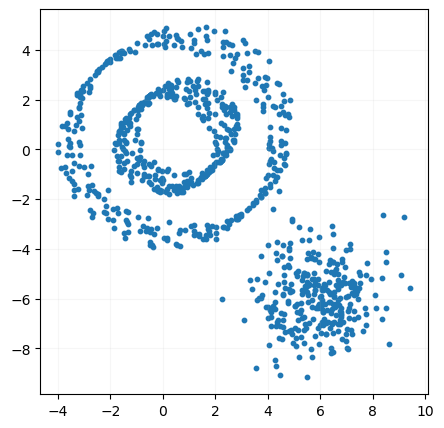

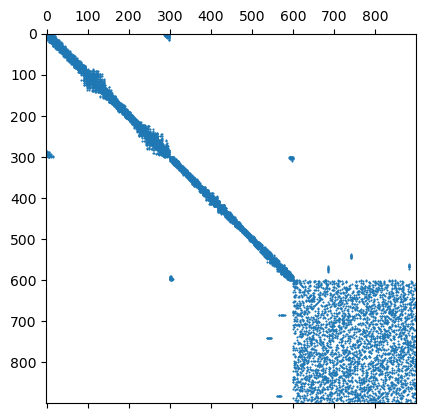

In [184]:
circle_df = read_file("Circle.csv", ['x', 'y'])

circle_ds = circle_df.values

circle_sc = SpectralClustering(circle_ds, 10, 1)
circle_sc.fit()

circle_W = circle_sc.W
circle_D = circle_sc.D
circle_L = circle_sc.L

circle_sc.plot_dataset()
circle_sc.plot_sparsity_pattern()

In [194]:
evalues, evectors = spsp.linalg.eigs(circle_W, k=898)

KeyboardInterrupt: 

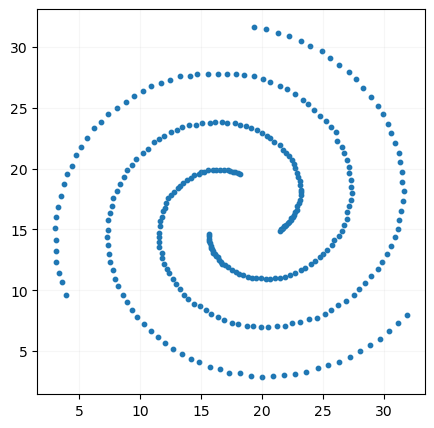

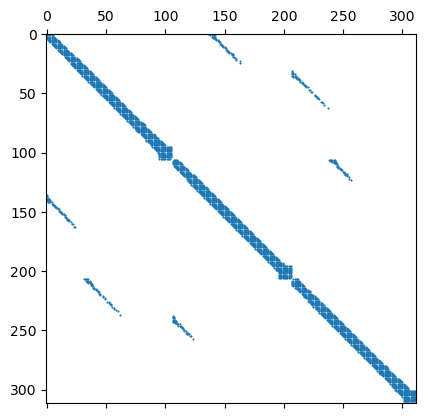

In [150]:
spiral_df = read_file("Spiral.csv", ['x', 'y', 'target'])
spiral_ds = spiral_df.loc[:, ['x','y']].values

spiral_sc = SpectralClustering(spiral_ds, 10, 1)
spiral_sc.fit()

spiral_W = spiral_sc.W
spiral_KNN = spiral_sc.KNN
spiral_D = spiral_sc.D
spiral_L = spiral_sc.L

spiral_sc.plot_dataset()
spiral_sc.plot_heatmap()